# Entrenamiento de Modelos

Como ya hemos explicado en la investigación, lo que nosotros haremos será entrenar diferentes modelos haciendo uso de los datos de entrenamiento. En este notebook crearemos modelos que hagan uso de los datos extraídos con MFCC en base a los datos originales (con preprocesamiento básico) chunkedos. De este modo, seguiremos el flujo básico de entrenamiento de modelos de ML:

1. Preprocesado de Datos. Esta parte ya fue realizada de manera previa con código python. En este caso, fue preprocesamiento básico.
2. Selección y Entrenamiento de Modelo.
    * Elegir algoritmo
    * Entrenar hiperparámetros
3. Evaluación de Resultados y Ajuste
4. Evaluación Final

Hay que tener en cuenta que estos datos chunkeados, en su mayoría, pueden llegar a representar información que no solo no aporte a la predicción de los modelos, si no que además pueda dañar o ir en contra de la robustez/aprendizaje o predicción del modelo. Esto se debe a la naturaleza de nuestros datos originales, tratandose de audios que son conversaciones entre el doctor y el paciente en el que habrá momentos de silencio, momentos en los que solo se escuche ruido clinico, momentos en los que intervengan otras personas (cocktail party).

Realmente, nos encontramos ante un dataset en el que la información extraible para el entrenamiento del modelo (habla del paciente), es la minoría, sin embargo, queremos desarrollar estos modelos para poder así demostrar de manera práctica, no solo teórica, la posibilidad del mal rendimiento siguiendo este baseline, sin aplicar ningún tipo de método de extracción anterior.

In [63]:
import pickle
import numpy as np
import pandas as pd
import mlflow

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


#Modelos
import joblib
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import PredefinedSplit
from lightgbm import LGBMClassifier

In [2]:
mlflow.set_tracking_uri("sqlite:///../resultados/resultados_voces.db")
mlflow.set_experiment("Clasificacion_Modelos_Clasicos_Notebooks")

<Experiment: artifact_location='file:///C:/Users/pedro/git/RepositorioInvestigacionTFG/notebooks/mlruns/3', creation_time=1781536250318, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781536250318, lifecycle_stage='active', name='Clasificacion_Modelos_Clasicos_Notebooks', tags={}, trace_location=None, workspace='default'>

In [3]:
#Cargamos dataset de Embedding con Pickle
ruta_train = '../datos_entrenamiento/train_mfcc_chunked.pkl'
ruta_test = '../datos_entrenamiento/test_mfcc_chunked.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

#Vamos a ver la información de nuestros datasets.
print("Forma del Dataset de entrenamiento:",df_train.shape)
print()
print("Encontrar datos nulos ---> ",df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:",df_test.shape)
print()
print("Encontrar datos nulos ---> ",df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (1248, 7)

Encontrar datos nulos --->  nombre_archivo    0
audio_original    0
chunk_id          0
mfccs             0
grupo             0
caja_toracica     0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (291, 7)

Encontrar datos nulos --->  nombre_archivo    0
audio_original    0
chunk_id          0
mfccs             0
grupo             0
caja_toracica     0
fold              0
dtype: int64

¿Hay valores nulos?:  False


En este caso, como sí hemos aplicado chunking de manera previa, todas las entradas de nuestro dataframe tendrán el mismo número de coeficientes. Es decir, estamos trabajando con un dataframe normalizado en cuanto a longitud de datos se refiere.

Esto nos permite trabajar de manera directa en la extracción de características en base a los coeficientes de mel, para así pasar directamente al entrenamiento de modelos. Los modelos que vamos a entrenar (RF, SVM y GB) requieren que todas las muestras del conjunto de datos tengan exactamente la misma dimensionalidad de entrada, y esto es algo que tenemos de base en este caso.

## Extracción Características

Antes de nada, tenemos que entender como funcionan los modelos con los que vamos a trabajar. Entre ellos, encontramos SVM: un modelo que no es capaz de trabajar con matrices, datos bidimensionales, solo con datos unidimensionales. 

Es por esto que, pese a que todos tengan la misma dimensionalidad, tenemos que aplicar aplanamiento, pero en este caso, podemos aplicarlo de manera distinta. Podemos aplicar flattening directo, ya que todos los datos tiene la misma dimensionalidad, pasando así de, para cada chunk: 30 coeficientes MFCC × 1000 frames temporales a 30000 features.

Sin embargo, esto puede que no sea en algunos casos siempre la mejor opción, aunque tengamos datos de misma dimensionalidad. Es por esto que también buscaremos trabajar con MFCCS aplanados con mean+std. Esta técnica es en muchos casos recomendada, ya que mitiga el riesgo asociado a la alta dimensionalidad (maldición dimensionalidad). Para poder trabajar de manera eficiente con el aplanamiento directo (30000 features), necesitamos en cambio tener una cantidad extremadamente elevada de datos, o en cambio, en base a este numero de features, generar uno menor. 

Con mean+std comprimimos la información en un vector denso de solo, por ejemplo, 60 características, lo cual no solo beneifica el tiempo de entrenamiento y el uso de memoria, si no que también puede llevar a una mejora en la capacidad de generalización de nuestro modelo.

In [4]:
#Funcion transformar datasets:
def generar_datasets_aplanados(df):
      metadatos = df[['nombre_archivo', 'audio_original', 'chunk_id', 'grupo', 'caja_toracica', 'fold']]
      n_mfcc = df['mfccs'].iloc[0].shape[0]

      # Dataset 1: Mean + Std (60 features)
      medias = pd.DataFrame(
          df['mfccs'].apply(lambda x: np.mean(x, axis=1)).tolist(),
          columns=[f'mfcc_media_{i+1}' for i in range(n_mfcc)],
          index=df.index
      )
      stds = pd.DataFrame(
          df['mfccs'].apply(lambda x: np.std(x, axis=1)).tolist(),
          columns=[f'mfcc_std_{i+1}' for i in range(n_mfcc)],
          index=df.index
      )
      df_pooling = pd.concat([metadatos, medias, stds], axis=1)

      # Dataset 2: Flatten completo (~30k features)
      df_flatten_features = pd.DataFrame(
          df['mfccs'].apply(lambda x: x.flatten()).tolist(),
          index=df.index
      )
      df_flatten = pd.concat([metadatos, df_flatten_features], axis=1)

      return df_pooling, df_flatten

df_train_pool, df_train_flat = generar_datasets_aplanados(df_train)
df_test_pool, df_test_flat = generar_datasets_aplanados(df_test)

In [5]:
print(f"Shape Train Plano: {df_train_flat.shape} + Shape Test Plano: {df_test_flat.shape}")
print(f"Shape Train Pooleado: {df_train_pool.shape} + Shape Test Pooleado: {df_test_pool.shape}")

Shape Train Plano: (1248, 30036) + Shape Test Plano: (291, 30036)
Shape Train Pooleado: (1248, 66) + Shape Test Pooleado: (291, 66)


### Extracción Características + Modelos DF_FLAT

Comenzaremos aplicando una reducción agresiva de características. Sin embargo, teniendo en cuenta la elevada dimensionalidad de las características, no podemos simplemente pasar a calcular la matriz de correlación, ya que supondría un coste computacional extremadamente elevado.

Sin embargo, podemos aplicar otra técnica que si nos pueda permitir reducir las características de manera agresiva, que es variance_threshold. Esta función permite eliminar todas aquellas características que tengan un valor menor o igual de varianza al que nosotros establezcamos.

In [6]:
columnas_a_quitar = ['nombre_archivo', 'caja_toracica', 'grupo', 'fold', 'audio_original', 'chunk_id']

X_train_num = df_train_flat.drop(columns=columnas_a_quitar)
X_test_num = df_test_flat.drop(columns=columnas_a_quitar)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

selector = VarianceThreshold(threshold=0.1)
X_train_filtered = selector.fit_transform(X_train_scaled)
X_test_filtered = selector.transform(X_test_scaled)

print(f"Features originales: {X_train_scaled.shape[1]} → tras VarianceThreshold: {X_train_filtered.shape[1]}")

Features originales: 30030 → tras VarianceThreshold: 30030


Como podemos observar, ni aplicando un threshold del 10% podemos reducir la dimensionalidad. Lo mejor puede ser pasar directamente a aplicar PCA y SelectKBest, en dos experimentos distintos.

#### PCA en FLAT

In [7]:
#Usamos un Scaler para aplicar PCA
scaler = StandardScaler()
subset_X = df_train_flat.drop(columns = columnas_a_quitar)
df_train_flat_transformed = scaler.fit_transform(subset_X)

pca = PCA()
df_train_pca = pca.fit_transform(df_train_flat_transformed)

# Ver varianza explicada. Con esto lo que buscamos es quedarnos con el número de predictores que 
#representar X% de los otros predictores.
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.0280207  0.05227032 0.06737132 ... 0.999792   0.9999992  0.9999992 ]


En este caso, iremos viendo con cuantas características nos podemos quedar con cada % de varianza, y eligiremos el numero que mejor nos venga.

In [8]:
#Numero de predictores con 95%
n_components_base = df_train_flat.drop(columns = columnas_a_quitar).shape[1]
print(f"Nº Componentes de base: {n_components_base}")
n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"Componentes necesarios para explicar el 95%: {n_components_95}")

#Numero de predictores con 90%
n_components_90 = np.argmax(cumulative_variance >= 0.90)
print(f"Componentes necesarios para explicar el 90%: {n_components_90}")

#Numero de predictores con 88%
n_components_88 = np.argmax(cumulative_variance >= 0.88)
print(f"Componentes necesarios para explicar el 88%: {n_components_88}")

#Numero de predictores con 85%
n_components_85 = np.argmax(cumulative_variance >= 0.85)
print(f"Componentes necesarios para explicar el 85%: {n_components_85}")

#Numero de predictores con 80%
n_components_80 = np.argmax(cumulative_variance >= 0.80)
print(f"Componentes necesarios para explicar el 80%: {n_components_80}")

#Numero de predictores con 75%
n_components_75 = np.argmax(cumulative_variance >= 0.75)
print(f"Componentes necesarios para explicar el 75%: {n_components_75}")

Nº Componentes de base: 30030
Componentes necesarios para explicar el 95%: 1072
Componentes necesarios para explicar el 90%: 929
Componentes necesarios para explicar el 88%: 877
Componentes necesarios para explicar el 85%: 804
Componentes necesarios para explicar el 80%: 694
Componentes necesarios para explicar el 75%: 595


Podemos observar como el nº de características se reduce considerablemente cuando tenemos un % de varianza específico. Sin embargo, no se reduce a un numero que pueda ser razonable de manejar por parte de los modelos. Tener 500 características como mínimo, con 1000 entradas, puede llevar a un situación que complique, no solo a nivel computacional, si no también la capidad de aprendizaje en el momento del entrenamiento del modelo.  

Por ello, vamos a elegir un numero de características fijo, ver que % varianza representa y elegir en base a dicho resultado que % de varianza representar.

In [9]:
print(f"Varianza explicada con 150 componentes: {cumulative_variance[149]:.4f}")

Varianza explicada con 150 componentes: 0.4098


Aun que perdamos bastante información, vamos a quedarnos con este numero de componentes (más bien, con el numero de componentes que representan el 45% de la varianza).

In [10]:
scaler = StandardScaler()
X_train_num = df_train_flat.drop(columns = columnas_a_quitar)
X_test_num = df_test_flat.drop(columns = columnas_a_quitar)

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

n_componentes = 0.45  # El valor que ya determinamos antes
pca = PCA(n_components=n_componentes, random_state=42)
X_train_pca_flat = pca.fit_transform(X_train_scaled)

#Con transform nos aseguramos de que no haya data leakage
X_test_pca_flat = pca.transform(X_test_scaled)

n_componentes_finales = X_train_pca_flat.shape[1]
print(f"El PCA ha seleccionado {n_componentes_finales} componentes principales.")

df_pca_train_flat = pd.DataFrame(
    X_train_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_train_flat.index
)
df_train_flat_1 = pd.concat([df_train_flat[columnas_a_quitar], df_pca_train_flat], axis=1)

df_pca_test_flat = pd.DataFrame(
    X_test_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_test_flat.index
)
df_test_flat_1 = pd.concat([df_test_flat[columnas_a_quitar], df_pca_test_flat], axis=1)

print("\nVista previa del conjunto de ENTRENAMIENTO post-pca:")
display(df_train_flat_1.head())

El PCA ha seleccionado 186 componentes principales.

Vista previa del conjunto de ENTRENAMIENTO post-pca:


,nombre_archivo,caja_toracica,grupo,fold,audio_original,chunk_id,MFCC_flat_pca1,MFCC_flat_pca2,MFCC_flat_pca3,MFCC_flat_pca4,...,MFCC_flat_pca177,MFCC_flat_pca178,MFCC_flat_pca179,MFCC_flat_pca180,MFCC_flat_pca181,MFCC_flat_pca182,MFCC_flat_pca183,MFCC_flat_pca184,MFCC_flat_pca185,MFCC_flat_pca186
0,Asma con CPAP urgencias_chunk000.wav,Obstructivo,Ventilación Invasiva,3,Asma con CPAP urgencias.m4a,0,24.601583,21.327349,10.138621,-15.408871,...,5.607640,-4.296891,1.295114,7.101135,3.030387,-5.729845,8.102468,-8.343812,-1.644627,12.257693
1,Asma con CPAP urgencias_chunk001.wav,Obstructivo,Ventilación Invasiva,3,Asma con CPAP urgencias.m4a,1,24.156763,21.807865,13.495871,5.731731,...,-6.031579,1.903907,4.885504,-3.335333,5.887765,3.179817,-3.479806,-1.715862,4.205835,-2.300046
2,Asma con CPAP urgencias_chunk002.wav,Obstructivo,Ventilación Invasiva,3,Asma con CPAP urgencias.m4a,2,-15.240899,7.352495,17.507170,11.338065,...,1.241320,4.383310,-1.909945,3.131356,-2.939411,-6.094240,2.024473,-10.181988,5.094493,-0.632089
3,Asma con CPAP urgencias_chunk003.wav,Obstructivo,Ventilación Invasiva,3,Asma con CPAP urgencias.m4a,3,-31.839348,7.577396,-6.333200,15.639653,...,-4.356071,-2.889616,0.201532,0.803563,-0.269050,10.609592,1.642152,-1.688560,1.515783,-3.503512
4,Asma con CPAP urgencias_chunk004.wav,Obstructivo,Ventilación Invasiva,3,Asma con CPAP urgencias.m4a,4,-28.746401,15.668891,-6.989873,-4.676535,...,-4.965714,3.089227,-0.323650,-5.584887,3.475911,-1.873484,-6.012054,4.426471,-0.642483,-2.569552


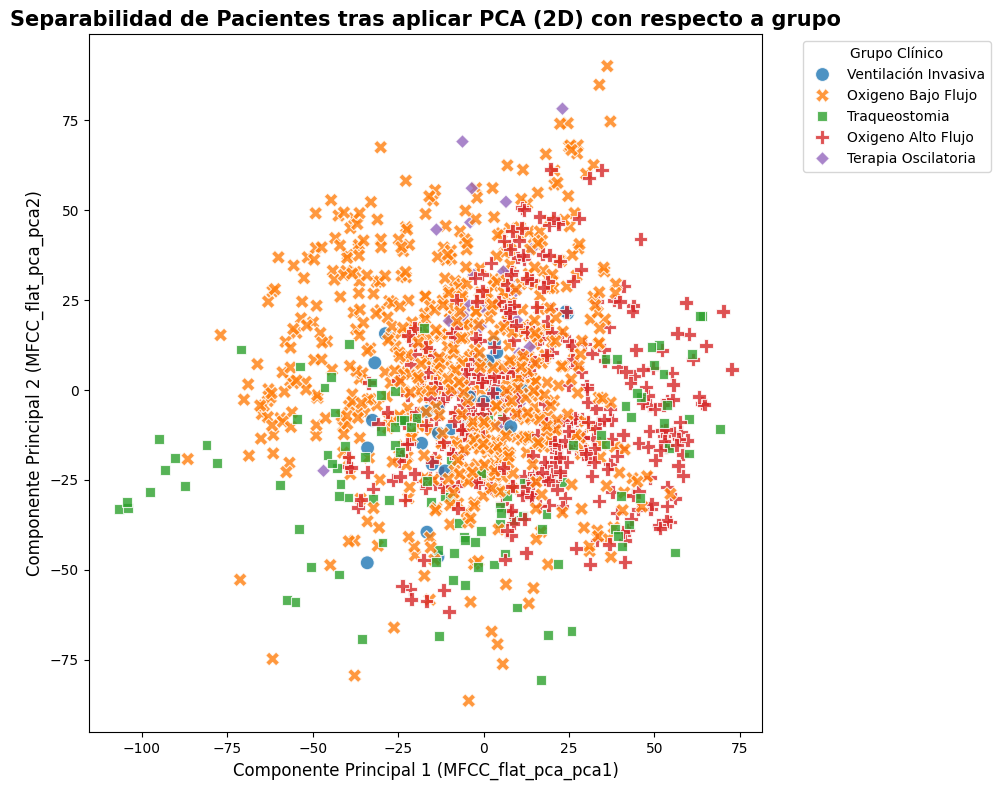

In [11]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_flat_1, 
    x='MFCC_flat_pca1', 
    y='MFCC_flat_pca2', 
    hue='grupo', 
    style='grupo', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a grupo', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupo Clínico')

plt.tight_layout()
plt.show()

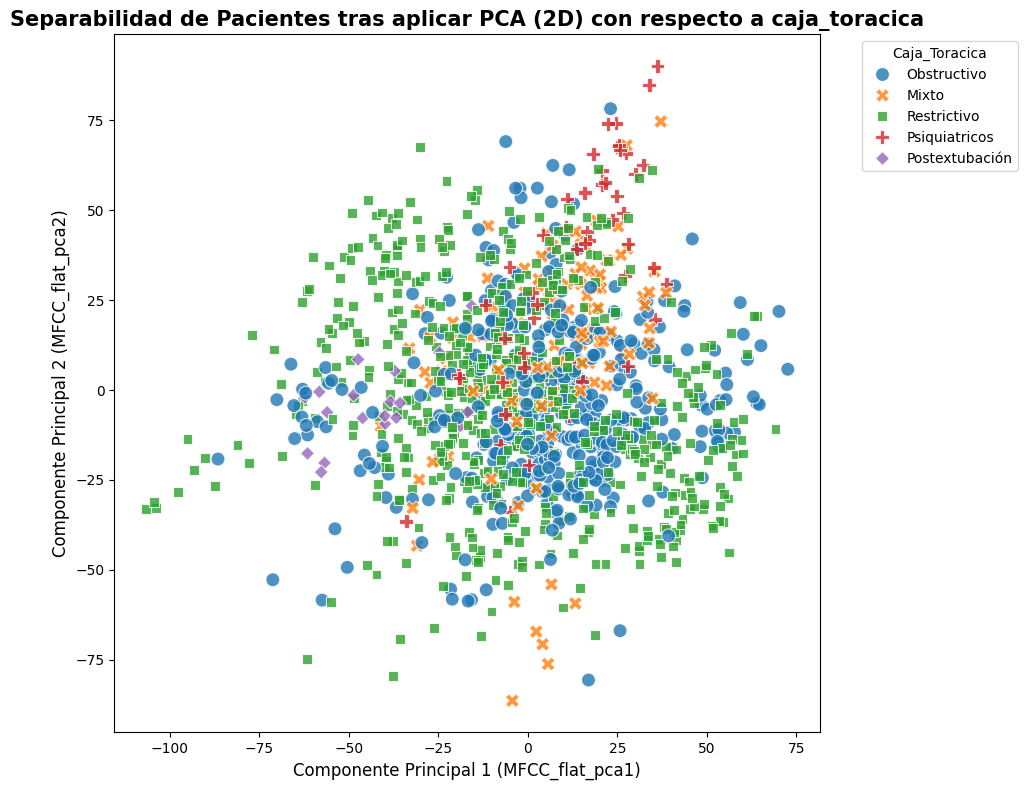

In [12]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_flat_1, 
    x='MFCC_flat_pca1', 
    y='MFCC_flat_pca2', 
    hue='caja_toracica', 
    style='caja_toracica', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a caja_toracica', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Caja_Toracica')

plt.tight_layout()
plt.show()

Con estos gráficos de dispersión buscamos representar cada chunk como un punto en un gráfico de coordenadas, teniendo en cuenta los valores de MFCC_flat_pca1 y MFCC_flat_pca2. Los 2 primeros componentes principales de un PCA son aquellas que agrupan mayor cantidad de información (varianza). En ambos gráficos podemos observar que no hay nubes de puntos claramente separadas. No hay una gran correlación entre los datos y el tipo de enfermedad con este tipo de procesamiento, por lo que podemos decir que se trata de una complejidad real. Necesitaremos ver que proyectan los modelos, pero de momento no creemos que se obtengan muy buenos resultados.

#### Entrenamiento Modelos Flat con PCA

Para este caso aplicaremos modelos básicos como SVM, RF o GB sobre los datos procesados de Embedding con pca (Primera ruta). Como hemos observado, los datos de momento no presentan mucha correlación con respecto al grupo o a la caja_toracica (patología). Esperamos que para este primer análisis no obtener resultados excesivamente excelentes.

In [13]:
from sklearn.metrics import make_scorer
scoring_cv = {
    'accuracy':    make_scorer(accuracy_score),
    'f1_macro':    make_scorer(f1_score, average='macro',    zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
}

def evaluar_modelo_pca_flat(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c = grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv",         acc_g)
    mlflow.log_metric("grupo_f1_macro_cv",    f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv",          acc_c)
    mlflow.log_metric("caja_f1_macro_cv",     f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",  f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [14]:
columnas_pca = [col for col in df_train_flat_1.columns if 'pca' in col]

X_train_model = df_train_flat_1[columnas_pca]
X_test_model = df_test_flat_1[columnas_pca]

y_train_grupo = df_train_flat_1['grupo']
y_test_grupo = df_test_flat_1['grupo']

y_train_caja = df_train_flat_1['caja_toracica']
y_test_caja = df_test_flat_1['caja_toracica']

In [15]:
folds_oficiales = df_train_flat_1['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

In [16]:
#Tunearemos los hiperparámetros con las ejecuciones y veremos cuales son las mejores configuraciones para cada modelo. Para cada uno haremos que la ejecución inicial sea con 
#hiperparámetros base de la documentación

#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_PCA_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 56.88% | F1-Macro: 20.78% (+/-7.69%) | F1-Weighted: 44.31%
[CV] Caja  - Acc: 47.61% | F1-Macro: 21.66% (+/-4.55%) | F1-Weighted: 36.86%


In [17]:
param_grid_rf_1 = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_PCA_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 56.88% | F1-Macro: 20.78% (+/-7.69%) | F1-Weighted: 44.31%
[CV] Caja  - Acc: 46.47% | F1-Macro: 21.70% (+/-5.69%) | F1-Weighted: 36.46%


In [18]:
param_grid_rf_2_grupo = {
    'n_estimators': [50, 100, 250],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_2_caja = {
    'n_estimators': [50, 100, 250],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_PCA_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat")

C:\Users\pedro\miniconda3\envs\env_audio_avanzado\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
[CV] Grupo - Acc: 55.68% | F1-Macro: 21.69% (+/-7.07%) | F1-Weighted: 44.94%
[CV] Caja  - Acc: 45.11% | F1-Macro: 22.66% (+/-5.68%) | F1-Weighted: 36.71%


In [19]:
param_grid_rf_final_grupo = {
    'n_estimators': [50],      
    'max_depth': [None],        
    'min_samples_split': [5],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_3_caja = {
    'n_estimators': [50],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_PCA_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
[CV] Grupo - Acc: 55.68% | F1-Macro: 21.69% (+/-7.07%) | F1-Weighted: 44.94%
[CV] Caja  - Acc: 45.11% | F1-Macro: 22.66% (+/-5.68%) | F1-Weighted: 36.71%


##### SVM

In [20]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_PCA_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat")


Mejores Hiperparámetros Grupo: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 53.53% | F1-Macro: 27.65% (+/-4.13%) | F1-Weighted: 52.37%
[CV] Caja  - Acc: 33.58% | F1-Macro: 20.77% (+/-4.95%) | F1-Weighted: 31.50%


In [21]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_PCA_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat")


Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.53% | F1-Macro: 28.75% (+/-3.41%) | F1-Weighted: 53.72%
[CV] Caja  - Acc: 38.26% | F1-Macro: 23.48% (+/-6.43%) | F1-Weighted: 34.61%


In [22]:
param_grid_svm_grupo_pca_flat = {
    'C': [0.5, 2.0, 2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_caja_pca_flat = {
    'C': [1.5, 2.0, 2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_PCA_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_grupo_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_caja_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.53% | F1-Macro: 28.75% (+/-3.41%) | F1-Weighted: 53.72%
[CV] Caja  - Acc: 38.26% | F1-Macro: 23.48% (+/-6.43%) | F1-Weighted: 34.61%


In [23]:
param_grid_svm_grupo_pca_flat_final = {
    'C': [0.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_caja_pca_flat_final = {
    'C': [1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_PCA_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_grupo_pca_flat_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_caja_pca_flat_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 54.53% | F1-Macro: 28.75% (+/-3.41%) | F1-Weighted: 53.72%
[CV] Caja  - Acc: 38.26% | F1-Macro: 23.48% (+/-6.43%) | F1-Weighted: 34.61%


#### LightGBM

En lugar del `GradientBoostingClassifier` de scikit-learn, utilizaremos **LightGBM** (*Light Gradient Boosting Machine*). Ambos pertenecen a la familia de *gradient boosting*, pero difieren fundamentalmente en cómo construyen los árboles.

El GB clásico de scikit-learn evalúa todos los posibles valores de corte para cada característica en cada nodo, con una complejidad aproximada de **O(T × n × d)** —siendo *T* el número de estimadores, *n* las muestras y *d* las características—, y lo hace de forma **secuencial** sin paralelización interna.

LightGBM resuelve esto mediante árboles basados en **histogramas**: discretiza los valores de cada característica en un número fijo de bins (255 por defecto), reduciendo el coste de búsqueda de splits a **O(T × bins × d)**, independientemente del número de muestras. En nuestro caso concreto, trabajamos con 1074 muestras de entrenamiento tras el chunking, lo que unido a las 171 características PCA hace que el GB clásico sea desproporcionadamente costoso. Adicionalmente, LightGBM soporta paralelización interna en la construcción de árboles, a diferencia del GB clásico.

Otra ventaja es que LightGBM acepta el parámetro `class_weight='balanced'` de forma nativa, por lo que no es necesario calcular `sample_weight` manualmente como en el GB de scikit-learn.

In [24]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_PCA_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat")


Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
[CV] Grupo - Acc: 52.41% | F1-Macro: 24.53% (+/-5.44%) | F1-Weighted: 48.44%
[CV] Caja  - Acc: 41.12% | F1-Macro: 17.73% (+/-3.72%) | F1-Weighted: 36.92%


In [25]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_PCA_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 63}
[CV] Grupo - Acc: 52.48% | F1-Macro: 26.15% (+/-7.99%) | F1-Weighted: 48.62%
[CV] Caja  - Acc: 40.13% | F1-Macro: 18.81% (+/-4.94%) | F1-Weighted: 36.06%


In [26]:
param_grid_lgbm_2_pca_grupo_flat = {
    'n_estimators': [100, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [63, 93],
    'max_depth': [-1],
    'min_child_samples': [20]
}


param_grid_lgbm_2_pca_caja_flat = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [63, 93],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_PCA_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_pca_grupo_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_pca_caja_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 63}
[CV] Grupo - Acc: 52.48% | F1-Macro: 26.15% (+/-7.99%) | F1-Weighted: 48.62%
[CV] Caja  - Acc: 40.13% | F1-Macro: 18.81% (+/-4.94%) | F1-Weighted: 36.06%


In [27]:
param_grid_lgbm_final_grupo_pca_flat = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [63],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_final_caja_pca_flat = {
    'n_estimators': [200],
    'learning_rate': [0.1],
    'num_leaves': [63],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_PCA_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 63}
[CV] Grupo - Acc: 52.48% | F1-Macro: 26.15% (+/-7.99%) | F1-Weighted: 48.62%
[CV] Caja  - Acc: 40.13% | F1-Macro: 18.81% (+/-4.94%) | F1-Weighted: 36.06%


#### SelectKBest en FLAT

Nosotros, para hacer la selección supervisada de características usando de la técnica SelectKBest, seleccionaremos las mejores características para grupo y las mejores características para caja toracica: esto nos llevaría a tener dos datasets distintos, uno para cada clase a predecir.

In [64]:
#Separamos valores a usar en la predicción de las otras columnas:
X_train_num = df_train_flat.drop(columns=columnas_a_quitar)
X_test_num = df_test_flat.drop(columns=columnas_a_quitar)

#Escalamos valores
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

#Obtenemos metadatos
meta_train = df_train_flat[columnas_a_quitar].reset_index(drop=True)
meta_test = df_test_flat[columnas_a_quitar].reset_index(drop=True)

In [65]:
y_train_grupo = meta_train['grupo']
y_test_grupo = meta_test['grupo']

y_train_caja = meta_train['caja_toracica']
y_test_caja = meta_test['caja_toracica']

K_FEATURES = 75 #Seleccionamos las 75 mejores características.

# Seleccionamos tener 75 características. Se trata de un número relativamente bajo de características comparado con el número de características que teníamos originalmente (30030). 
#Este número puede evitar tanto un posible sobre-entrenamiento como la maldición de la dimensionalidad, ya que mantenemos una relación razonable entre muestras y características. 

#### Entrenamiento de modelos

Ahora podemos pasar directamente a hacer el entrenamiento de modelos, pero usando los conjuntos de datos "selected"

##### RF

In [66]:
def evaluar_modelo_kbest_flat(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c= grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c= grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv", f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv",f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [67]:
folds_oficiales = df_train_flat['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

In [68]:
param_grid_rf = {
    'clf__n_estimators': [100],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [2],   
    'clf__min_samples_leaf': [1],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - FLAT"
    )


Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
[CV] Grupo - Acc: 57.29% | F1-Macro: 28.22% (+/-6.16%) | F1-Weighted: 52.06%
[CV] Caja  - Acc: 43.83% | F1-Macro: 20.38% (+/-4.71%) | F1-Weighted: 37.85%


In [69]:
param_grid_rf_1 = {
    'clf__n_estimators': [100, 150],      
    'clf__max_depth': [None, 10, 20],        
    'clf__min_samples_split': [2, 5],   
    'clf__min_samples_leaf': [1, 2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - FLAT"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 150}
[CV] Grupo - Acc: 55.62% | F1-Macro: 30.32% (+/-6.29%) | F1-Weighted: 52.92%
[CV] Caja  - Acc: 44.04% | F1-Macro: 22.51% (+/-3.66%) | F1-Weighted: 38.04%


In [70]:
param_grid_rf_2_grupo = {
    'clf__n_estimators': [100, 200, 250],      
    'clf__max_depth': [None, 10],        
    'clf__min_samples_split': [5, 7],   
    'clf__min_samples_leaf': [1, 2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

param_grid_rf_2 = {
    'clf__n_estimators': [150, 200, 250],      
    'clf__max_depth': [None, 20],        
    'clf__min_samples_split': [2, 5],   
    'clf__min_samples_leaf': [1, 2],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - FLAT"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 150}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
[CV] Grupo - Acc: 56.02% | F1-Macro: 28.40% (+/-5.93%) | F1-Weighted: 52.07%
[CV] Caja  - Acc: 44.22% | F1-Macro: 24.11% (+/-6.87%) | F1-Weighted: 37.85%


In [71]:
param_grid_rf_final_kbest_grupo_flat = {
    'clf__n_estimators': [100],      
    'clf__max_depth': [10],        
    'clf__min_samples_split': [5],   
    'clf__min_samples_leaf': [1],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

param_grid_rf_final_kbest_caja_flat = {
    'clf__n_estimators': [200],      
    'clf__max_depth': [None],        
    'clf__min_samples_split': [2],   
    'clf__min_samples_leaf': [1],    
    'clf__max_features': ['sqrt'], 
    'clf__bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    grid_rf_grupo = GridSearchCV(pipeline_grupo, param_grid_rf_final_kbest_grupo_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])

    
    grid_rf_caja = GridSearchCV(pipeline_caja, param_grid_rf_final_kbest_caja_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="Random Forest - SelectKBest=75 - FLAT"
    )

Mejores Hiperparámetros Grupo: {'clf__bootstrap': True, 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Mejores Hiperparámetros Caja:  {'clf__bootstrap': True, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
[CV] Grupo - Acc: 55.62% | F1-Macro: 30.32% (+/-6.29%) | F1-Weighted: 52.92%
[CV] Caja  - Acc: 44.22% | F1-Macro: 24.11% (+/-6.87%) | F1-Weighted: 37.85%


#### SVM

In [72]:
param_grid_svm = {
    'clf__C': [1.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 40.00% | F1-Macro: 23.36% (+/-4.23%) | F1-Weighted: 45.02%
[CV] Caja  - Acc: 29.59% | F1-Macro: 16.05% (+/-2.04%) | F1-Weighted: 30.61%


In [73]:
param_grid_svm_1 = {
    'clf__C': [0.5, 1.0, 1.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 42.79% | F1-Macro: 23.66% (+/-4.53%) | F1-Weighted: 46.69%
[CV] Caja  - Acc: 30.67% | F1-Macro: 16.42% (+/-2.29%) | F1-Weighted: 31.45%


In [74]:
param_grid_svm_2_kbest_flat = {
    'clf__C': [1.5, 2.0, 3.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 3.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 42.79% | F1-Macro: 23.66% (+/-4.53%) | F1-Weighted: 46.69%
[CV] Caja  - Acc: 32.60% | F1-Macro: 17.23% (+/-3.27%) | F1-Weighted: 33.06%


In [75]:
param_grid_svm_final_kbest_grupo_flat = {
    'clf__C': [1.5],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

param_grid_svm_final_kbest_caja_flat = {
    'clf__C': [3.0],
    'clf__kernel': ['rbf'],
    'clf__gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para cada objetivo
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])

    grid_svm_grupo = GridSearchCV(pipeline_grupo, param_grid_svm_final_kbest_grupo_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', SVC(class_weight='balanced', random_state=42))
    ])
    
    grid_svm_caja = GridSearchCV(pipeline_caja, param_grid_svm_final_kbest_caja_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="SVM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'clf__C': 3.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
[CV] Grupo - Acc: 42.79% | F1-Macro: 23.66% (+/-4.53%) | F1-Weighted: 46.69%
[CV] Caja  - Acc: 32.60% | F1-Macro: 17.23% (+/-3.27%) | F1-Weighted: 33.06%


#### LightGBM

In [76]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'clf__n_estimators': [100],
    'clf__learning_rate': [0.1],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1],
    'clf__min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__min_child_samples': 20, 'clf__n_estimators': 100, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 52.84% | F1-Macro: 21.08% (+/-0.35%) | F1-Weighted: 49.91%
[CV] Caja  - Acc: 40.15% | F1-Macro: 19.24% (+/-6.48%) | F1-Weighted: 38.10%


In [77]:
param_grid_lgbm_1 = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__num_leaves': [31, 63],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([   
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.05, 'clf__max_depth': -1, 'clf__min_child_samples': 50, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 53.45% | F1-Macro: 24.41% (+/-3.87%) | F1-Weighted: 50.31%
[CV] Caja  - Acc: 39.52% | F1-Macro: 19.96% (+/-6.09%) | F1-Weighted: 38.31%


In [78]:
param_grid_lgbm_2_grupo_kbest_flat = {
    'clf__n_estimators': [200, 300],
    'clf__learning_rate': [0.1, 0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1,10],
    'clf__min_child_samples': [20]
}

param_grid_lgbm_2_caja_kbest_flat = {
    'clf__n_estimators': [200, 300],
    'clf__learning_rate': [0.05, 0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [-1, 10],
    'clf__min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_2_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])
    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_2_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.15, 'clf__max_depth': 10, 'clf__min_child_samples': 50, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 53.45% | F1-Macro: 24.41% (+/-3.87%) | F1-Weighted: 50.31%
[CV] Caja  - Acc: 40.49% | F1-Macro: 20.07% (+/-7.20%) | F1-Weighted: 38.55%


In [79]:
param_grid_lgbm_3_grupo_kbest_flat = {
    'clf__n_estimators': [200, 400],
    'clf__learning_rate': [0.1],
    'clf__num_leaves': [31],
    'clf__max_depth': [10],
    'clf__min_child_samples': [20]
}

param_grid_lgbm_3_caja_kbest_flat = {
    'clf__n_estimators': [200, 400],
    'clf__learning_rate': [0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [10],
    'clf__min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])
    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_3_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])

    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_3_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.15, 'clf__max_depth': 10, 'clf__min_child_samples': 50, 'clf__n_estimators': 400, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 53.45% | F1-Macro: 24.41% (+/-3.87%) | F1-Weighted: 50.31%
[CV] Caja  - Acc: 41.12% | F1-Macro: 20.26% (+/-7.34%) | F1-Weighted: 39.18%


In [80]:
param_grid_lgbm_final_grupo_kbest_flat = {
    'clf__n_estimators': [200],
    'clf__learning_rate': [0.1],
    'clf__num_leaves': [31],
    'clf__max_depth': [10],
    'clf__min_child_samples': [20]
}

param_grid_lgbm_final_caja_kbest_flat = {
    'clf__n_estimators': [400],
    'clf__learning_rate': [0.15],
    'clf__num_leaves': [31],
    'clf__max_depth': [10],
    'clf__min_child_samples': [50]
}

with mlflow.start_run(run_name="LGB_Chunking_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    pipeline_grupo = Pipeline([    
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])
    
    grid_lgbm_grupo = GridSearchCV(pipeline_grupo, param_grid_lgbm_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_scaled, y_train_grupo)
    
    pipeline_caja = Pipeline([
        ('selector', SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ('clf', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1))
    ])
    
    grid_lgbm_caja = GridSearchCV(pipeline_caja, param_grid_lgbm_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_scaled, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_scaled,
        X_test_caja=X_test_scaled,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat"
    )

Mejores Hiperparámetros Grupo: {'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 31}
Mejores Hiperparámetros Caja:  {'clf__learning_rate': 0.15, 'clf__max_depth': 10, 'clf__min_child_samples': 50, 'clf__n_estimators': 400, 'clf__num_leaves': 31}
[CV] Grupo - Acc: 53.45% | F1-Macro: 24.41% (+/-3.87%) | F1-Weighted: 50.31%
[CV] Caja  - Acc: 41.12% | F1-Macro: 20.26% (+/-7.34%) | F1-Weighted: 39.18%


### Extracción Características + Modelos DF_FLAT

En este caso, nos encontramos con un menos numero de componentes, por lo que simplemente podemos aplicar una reducción de características basándonos en matrices y mapas de correlación, eliminando aquellos datos que no aporten varianza al sistema, debido a que estén extremadamente correlacionados entre ellos. 

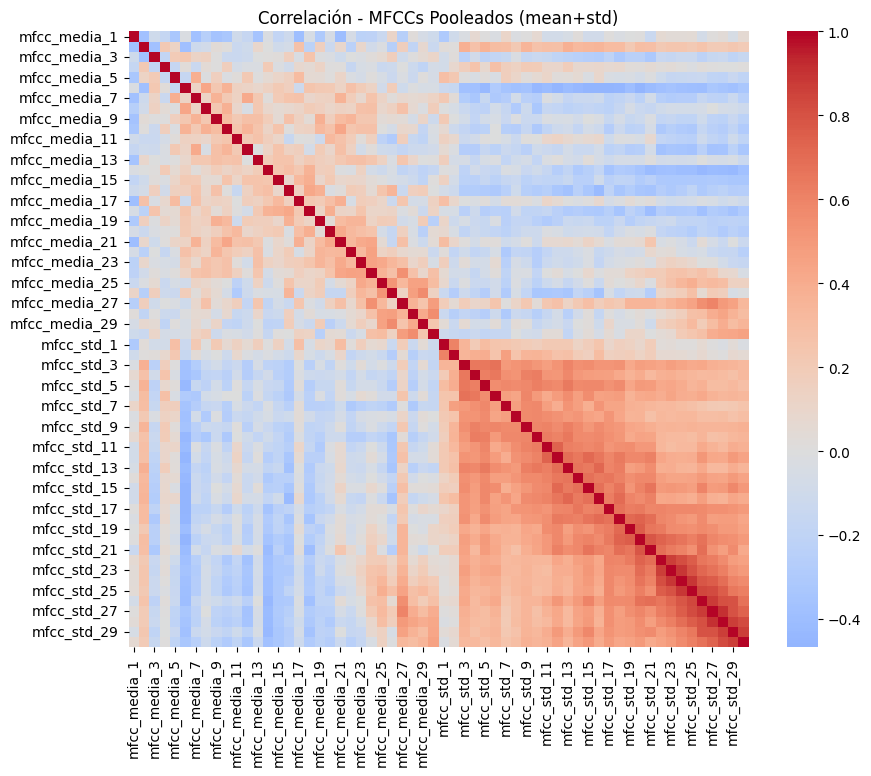

In [45]:
columnas_a_quitar = ['nombre_archivo', 'audio_original', 'chunk_id', 'grupo', 'caja_toracica', 'fold']

X_train = df_train_pool.drop(columns=columnas_a_quitar)

#Calculamos la matriz de correlación
corr_matrix = X_train.corr()

def plot_corr(df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlación - {title}")
    plt.show()

plot_corr(X_train,"MFCCs Pooleados (mean+std)")

Con esto podemos observar que no hay muchos componentes que estén correlacionados entre sí, excepto por los últimos valores de desviación estándar, los cuales presentan una mayor correlación positiva entre sí. 

En el caso de que observemos valores de correlación elevados entre features, podremos simplemente eliminarlos, ya que aportan información redundante. Si reducimos la dimensionalidad, nuestro modelo se protegerá del sobreaprendizaje y el entrenamiento no será tan costoso.

In [46]:
#Vamos a comprobar la correlación de todas las columnas mfcc_std, y ver si alguna supera cierto umbral
#Este umbral será del 80%, simplemente lo establecemos para ver si alguna de las características supera al menos el 80% de correlación.
columnas_correlacionadas = [f'mfcc_std_{i}' for i in range(1, 31)]
X_correlacionado = X_train[columnas_correlacionadas]

umbral = 0.8
matriz_corr_sub = X_correlacionado.corr()
for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        col1 = matriz_corr_sub.columns[i]
        col2 = matriz_corr_sub.columns[j]
        correlacion = matriz_corr_sub.iloc[i, j]
        if(correlacion >= umbral):
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")

mfcc_std_23 y mfcc_std_22 -> Correlación: 0.865
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.816
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.890
mfcc_std_25 y mfcc_std_23 -> Correlación: 0.802
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.895
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.836
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.826
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.878
mfcc_std_28 y mfcc_std_26 -> Correlación: 0.809
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.904
mfcc_std_29 y mfcc_std_28 -> Correlación: 0.867
mfcc_std_30 y mfcc_std_28 -> Correlación: 0.818
mfcc_std_30 y mfcc_std_29 -> Correlación: 0.867


Con esto podemos ver que hay muchas características que tienen mas del 80% de correlación, sin embargo, muy pocas son las que superan el 85% y solo una pareja supera el 90%.
En este caso, vamos a eliminar aquellas características que superen el 88% de correlación, tratandose de un valor elevado que nos permite reducir la redundancia entre características altamente correlacionadas sin perder información relevante. De este modo, mantenemos la mayor parte de la varianza del espacio original mientras eliminamos únicamente aquellos pares de características que aportan información prácticamente idéntica al modelo.

In [47]:
umbral = 0.88
pares_a_eliminar = set()

matriz_correlacion = X_train.corr()
for i in range(len(matriz_correlacion.columns)):
    for j in range(i):
        if abs(matriz_correlacion.iloc[i, j]) > umbral:
            col1 = matriz_correlacion.columns[i]
            col2 = matriz_correlacion.columns[j]
            correlacion = matriz_correlacion.iloc[i, j]
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")
            
            pares_a_eliminar.add(col1)

print("Columnas a eliminar: ")
print(f"{list(pares_a_eliminar)}. Número total = {len(pares_a_eliminar)}")

#Las eliminamos:
X_pool_reducido_train = df_train_pool.drop(columns = pares_a_eliminar)
X_pool_reducido_test = df_test_pool.drop(columns = pares_a_eliminar)

mfcc_std_24 y mfcc_std_23 -> Correlación: 0.890
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.895
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.904
Columnas a eliminar: 
['mfcc_std_24', 'mfcc_std_28', 'mfcc_std_25']. Número total = 3


In [48]:
X_pool_reducido_train.head()

,nombre_archivo,audio_original,chunk_id,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,...,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_23,mfcc_std_26,mfcc_std_27,mfcc_std_29,mfcc_std_30
0,Asma con CPAP urgencias_chunk000.wav,Asma con CPAP urgencias.m4a,0,Ventilación Invasiva,Obstructivo,3,-352.684570,121.787636,6.224621,27.935034,...,8.405086,7.996205,7.939536,8.150311,8.694556,9.045935,9.260821,9.394863,8.406208,8.015336
1,Asma con CPAP urgencias_chunk001.wav,Asma con CPAP urgencias.m4a,1,Ventilación Invasiva,Obstructivo,3,-339.487823,123.426231,9.730461,32.741390,...,8.455305,7.836003,7.804312,8.876750,7.445955,7.534163,7.528830,7.966033,8.578970,7.592166
2,Asma con CPAP urgencias_chunk002.wav,Asma con CPAP urgencias.m4a,2,Ventilación Invasiva,Obstructivo,3,-399.016174,132.183716,13.481374,33.678719,...,7.418018,7.271252,6.891327,7.456121,7.929958,7.214566,6.502168,6.298608,6.391878,6.329375
3,Asma con CPAP urgencias_chunk003.wav,Asma con CPAP urgencias.m4a,3,Ventilación Invasiva,Obstructivo,3,-395.205505,140.998642,-1.504796,25.808960,...,8.010357,7.082330,8.166845,8.507314,6.895773,7.064053,7.885747,6.630590,6.614004,6.349296
4,Asma con CPAP urgencias_chunk004.wav,Asma con CPAP urgencias.m4a,4,Ventilación Invasiva,Obstructivo,3,-397.477325,142.401291,-9.678452,26.974434,...,7.728837,7.758575,7.587714,7.138915,7.763618,6.839456,6.737214,6.744145,6.882489,6.559583


In [49]:
X_pool_reducido_test.head()

,nombre_archivo,audio_original,chunk_id,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,...,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_23,mfcc_std_26,mfcc_std_27,mfcc_std_29,mfcc_std_30
0,Asma obesidad grave vni planta_chunk000.wav,Asma obesidad grave vni planta.m4a,0,Ventilación Invasiva,Obstructivo,-1,-351.863068,106.542160,4.947843,13.515463,...,7.285684,7.209405,7.575176,7.960977,7.602012,6.996829,7.451983,7.202028,7.094824,7.444332
1,Asma obesidad grave vni planta_chunk001.wav,Asma obesidad grave vni planta.m4a,1,Ventilación Invasiva,Obstructivo,-1,-393.288605,131.573517,-2.345975,5.945772,...,7.435338,7.038389,7.185234,6.782732,6.558898,7.233943,7.337729,7.652472,8.119221,8.108114
2,Asma obesidad grave vni planta_chunk002.wav,Asma obesidad grave vni planta.m4a,2,Ventilación Invasiva,Obstructivo,-1,-365.639435,131.818985,-2.072165,16.053932,...,7.831313,7.243642,7.226472,6.781689,6.940420,7.160105,7.758900,8.005737,7.901624,7.661132
3,Asma obesidad grave vni planta_chunk003.wav,Asma obesidad grave vni planta.m4a,3,Ventilación Invasiva,Obstructivo,-1,-393.031647,130.891052,-3.190361,1.497378,...,7.616788,7.390032,8.201317,7.395317,7.481059,8.400870,8.124797,7.900792,7.295523,7.487084
4,Asma obesidad grave vni planta_chunk004.wav,Asma obesidad grave vni planta.m4a,4,Ventilación Invasiva,Obstructivo,-1,-388.963470,129.496872,-4.107275,0.907438,...,7.979238,7.489220,7.864351,7.285964,7.486277,7.826944,8.965296,7.901580,7.593573,7.646188


En este caso, creemos que tenemos un numero bastante reducido de características con el que trabajar, por lo que pasaremos directamente al entrenamiento de modelos.

#### Entrenamiento de Modelos.

In [50]:
columnas_num = [col for col in X_pool_reducido_train.columns if 'mfcc' in col]

X_train_model = X_pool_reducido_train[columnas_num]
X_test_model = X_pool_reducido_test[columnas_num]

y_train_grupo = df_train_pool['grupo']
y_test_grupo = df_test_pool['grupo']

y_train_caja = df_train_pool['caja_toracica']
y_test_caja = df_test_pool['caja_toracica']

folds_oficiales = df_train_pool['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

def evaluar_modelo_pool(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g    = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g   = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g    = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c    = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c   = grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c    = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv",         acc_g)
    mlflow.log_metric("grupo_f1_macro_cv",    f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv",          acc_c)
    mlflow.log_metric("caja_f1_macro_cv",     f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",  f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [51]:
#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_pool_Simple_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 55.99% | F1-Macro: 24.14% (+/-8.97%) | F1-Weighted: 47.20%
[CV] Caja  - Acc: 46.40% | F1-Macro: 22.99% (+/-10.67%) | F1-Weighted: 37.54%


In [52]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_pool_Simple_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 55.89% | F1-Macro: 26.86% (+/-8.14%) | F1-Weighted: 49.60%
[CV] Caja  - Acc: 47.17% | F1-Macro: 26.34% (+/-10.24%) | F1-Weighted: 39.42%


In [53]:
param_grid_rf_2_grupo = {
    'n_estimators': [150, 200, 300],      
    'max_depth': [None, 10],        
    'min_samples_split': [5,7],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_2_caja = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [None, 10],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_pool_Simple_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 300}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 53.96% | F1-Macro: 27.75% (+/-7.98%) | F1-Weighted: 50.25%
[CV] Caja  - Acc: 47.17% | F1-Macro: 26.34% (+/-10.24%) | F1-Weighted: 39.42%


In [54]:
param_grid_rf_grupo_final_pool = {
    'n_estimators': [300],      
    'max_depth': [None],        
    'min_samples_split': [5],   
    'min_samples_leaf': [6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_caja_final_pool = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}
#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_pool_Simple_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
    
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_grupo_final_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_caja_final_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool")

Mejores Hiperparámetros Grupo: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 300}
Mejores Hiperparámetros Caja:  {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
[CV] Grupo - Acc: 53.96% | F1-Macro: 27.75% (+/-7.98%) | F1-Weighted: 50.25%
[CV] Caja  - Acc: 47.17% | F1-Macro: 26.34% (+/-10.24%) | F1-Weighted: 39.42%


#### SVM

In [55]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_pool_Simple_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
    
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool")

Mejores Hiperparámetros Grupo: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 32.11% | F1-Macro: 22.42% (+/-5.02%) | F1-Weighted: 39.17%
[CV] Caja  - Acc: 28.65% | F1-Macro: 17.93% (+/-3.30%) | F1-Weighted: 31.27%


In [56]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_pool_Simple_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
    
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool")

Mejores Hiperparámetros Grupo: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros Caja:  {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
[CV] Grupo - Acc: 32.55% | F1-Macro: 23.06% (+/-6.60%) | F1-Weighted: 38.86%
[CV] Caja  - Acc: 28.65% | F1-Macro: 17.93% (+/-3.30%) | F1-Weighted: 31.27%


Resultados malos con SVM, no seguiremos tuneando.

#### LigthGBM

In [57]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_pool_Simple_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
[CV] Grupo - Acc: 53.92% | F1-Macro: 27.89% (+/-8.52%) | F1-Weighted: 51.31%
[CV] Caja  - Acc: 44.56% | F1-Macro: 21.93% (+/-6.26%) | F1-Weighted: 40.47%


In [58]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_pool_Simple_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
[CV] Grupo - Acc: 53.92% | F1-Macro: 30.43% (+/-9.35%) | F1-Weighted: 51.15%
[CV] Caja  - Acc: 44.55% | F1-Macro: 22.58% (+/-5.44%) | F1-Weighted: 40.64%


In [60]:
param_grid_lgbm_2_grupo_pool = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [63, 93],
    'max_depth': [-1,10],
    'min_child_samples': [20]
}

param_grid_lgbm_2_caja_pool = {
    'n_estimators': [50, 100, 250],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [63,93],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_pool_Simple_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.15, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
[CV] Grupo - Acc: 53.96% | F1-Macro: 33.90% (+/-14.23%) | F1-Weighted: 51.58%
[CV] Caja  - Acc: 44.55% | F1-Macro: 22.58% (+/-5.44%) | F1-Weighted: 40.64%


In [62]:
param_grid_final_lgbm_grupo_pool = {
    'n_estimators': [200],
    'learning_rate': [0.15],
    'num_leaves': [63],
    'max_depth': [10],
    'min_child_samples': [20]
}

param_grid_final_lgbm_caja_pool = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [63],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_pool_Simple_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
    
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_final_lgbm_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_final_lgbm_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool")

Mejores Hiperparámetros Grupo: {'learning_rate': 0.15, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 63}
Mejores Hiperparámetros Caja:  {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 63}
[CV] Grupo - Acc: 53.96% | F1-Macro: 33.90% (+/-14.23%) | F1-Weighted: 51.58%
[CV] Caja  - Acc: 44.55% | F1-Macro: 22.58% (+/-5.44%) | F1-Weighted: 40.64%


## Evaluación Final: Test

El rendimiento de los modelos obtenidos en base a este conjunto de datos es inferior al de otros conjuntos de datos, por lo que no haremos test final sobre este conjunto